# Import Libraries

In [17]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [18]:
probabilities = pd.read_csv("../data/results/wc2026_predictions_10,000_20260613_1140.csv")

# Visualisations
## Most Likely Winners

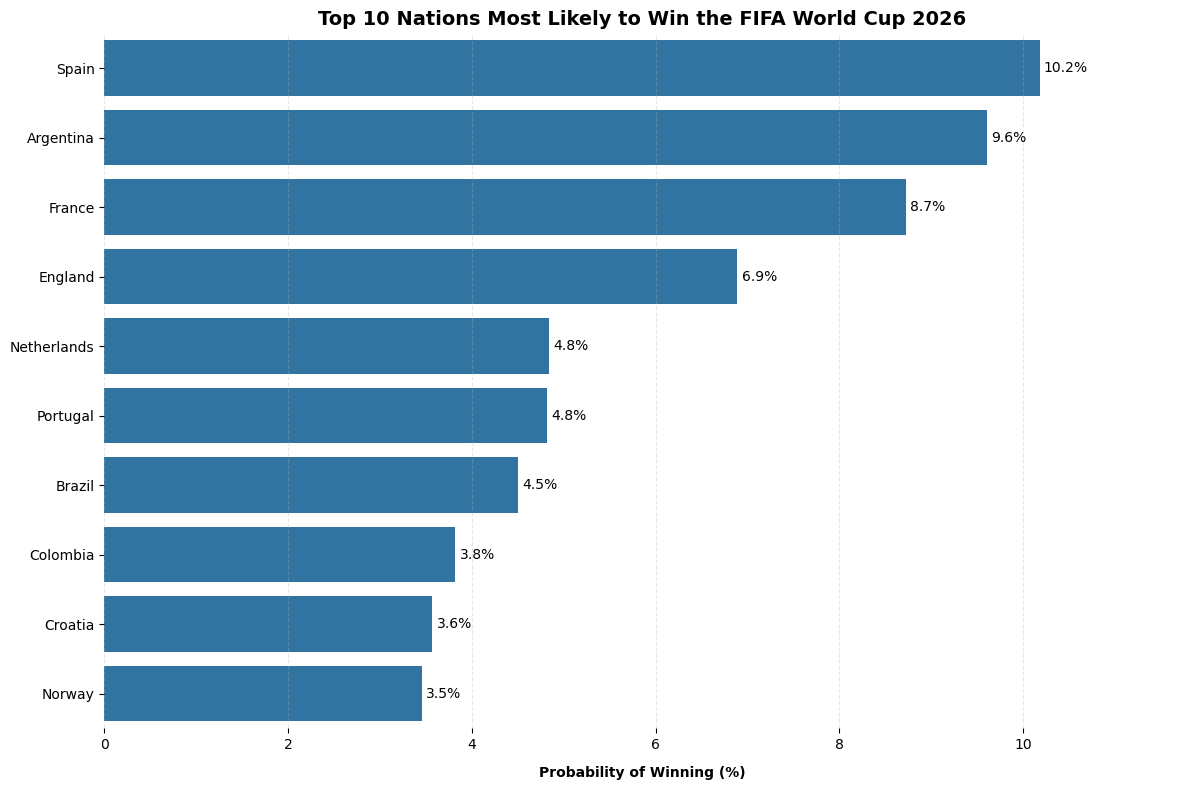

In [23]:
most_likely_winners = probabilities.head(10).copy()
most_likely_winners["champion_prob"] = most_likely_winners["champion_prob"].apply(lambda x: x*100)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=most_likely_winners,
    x="champion_prob",
    y="country"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.title("Top 10 Nations Most Likely to Win the FIFA World Cup 2026", fontsize=14, fontweight="bold")
plt.xlabel("Probability of Winning (%)", labelpad=10, fontweight="bold")
plt.ylabel("")

# Remove unnecessary borders
sns.despine(left=True, bottom=True)

# Add subtle gridlines
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Leave some room for labels
plt.xlim(0, most_likely_winners["champion_prob"].max() * 1.15)

plt.tight_layout()

plt.show()

According to the model, the top 3 contenders to win the 2026 FIFA World Cup are Spain, Argentina and France. Spain emerges as the country with the highest probability at 10.2%. This result aligns closely with current perceptions of international football, as well as other well-known predictions.

Interestingly, the model also predicts Norway to be the dark horse of the tournament, with it appearing in the top 10 countries with the highest probability to win the world cup.

## Probability Heatmap

Heatmap of the odds for the top 15 most likely winners to reach each stage of the 2026 World Cup.

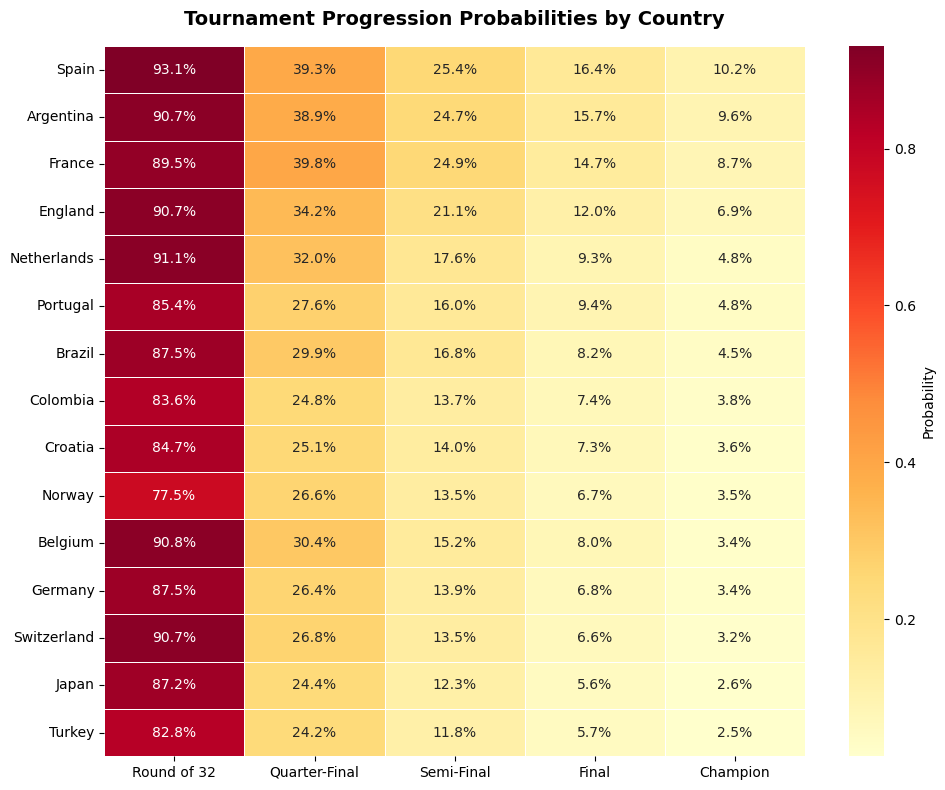

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

stages = probabilities[
    ["country",
     "r32_prob",
     "quarter_final_prob",
     "semi_final_prob",
     "final_prob",
     "champion_prob"]
].head(15)

sns.heatmap(
    stages.set_index("country"),
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Probability"},
    ax=ax
)

ax.set_title("Tournament Progression Probabilities by Country", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(
    ["Round of 32", "Quarter-Final", "Semi-Final", "Final", "Champion"],
    rotation=0
)

plt.tight_layout()
plt.show()

- Despite Norway having the tenth highest probability of winning the world cup, the probability of them reaching the Round of 32 is distinctly lower than that of other countries in the list of top 15 contenders.  
- Belgium, Switzerland, Germany and Japan have considerably high chances of reaching the Round of 32 and Quarter-Final, but face a lower chance of winning the tournament. 